<a href="https://colab.research.google.com/github/nguyentaman200802-web/ISOM835-Predictive-Analytics/blob/main/01_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load the dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Train.csv')

# Display the first 5 rows to make sure it worked
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
# Check exactly how many missing (null) values are in each column
df.isnull().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


## Data Set Selection
For this predictive analytics project, I have selected the E-Commerce Shipping Data sourced from Kaggle. This dataset contains 10,999 observations of international supply chain operations, capturing critical logistical variables such as warehouse block origins, modes of shipment, product weight, customer discount rates, and historical customer ratings. The primary predictive target is whether a shipment arrived on time or was delayed. This dataset was chosen because it represents a highly realistic, non-trivial operational scenario where data is not just analyzed in a vacuum, but directly impacts bottom-line performance and customer satisfaction.

The rationale for this selection is rooted in bridging technical machine learning with actionable business strategy. Supply chain bottlenecks are a major cost driver for e-commerce organizations. By building a model that accurately predicts late deliveries based on leading indicators (like product weight and warehouse routing), operations managers can proactively intervene—perhaps by upgrading shipping methods for high-risk packages or re-routing inventory to prevent fulfillment delays. This dataset allows for a complete lifecycle analysis, from exploratory data auditing to predictive modeling, ultimately translating raw logistical data into proactive business decisions.

## Business Questions

1. How does the originating warehouse block impact the likelihood of a delayed shipment?

    **Explanation**: If operations managers know certain facilities have higher delay rates, they can investigate local bottlenecks or temporarily route inventory to better-performing warehouses.

2. Is there a relationship between a product's weight, the chosen mode of shipment, and its on-time delivery rate?

    **Explanation**: Understanding this allows logistics teams to automatically mandate faster or more reliable shipping modes (like Flight vs. Ship) for specific weight classes to guarantee on-time arrival.

3. Do promotional strategies, such as higher customer discount rates, negatively impact fulfillment capacity and lead to delays?

    **Explanation**: If large discounts cause sudden spikes in order volume that the warehouse cannot handle, the business strategy team needs to coordinate with the warehouse managers before launching sales.

## Exploratory Data Analysis (EDA)

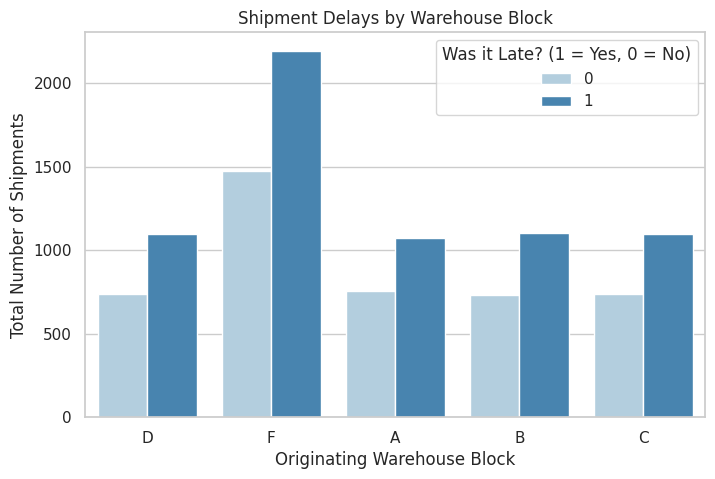

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make the charts look professional
sns.set_theme(style="whitegrid")

# Create a bar chart comparing warehouses and late deliveries
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Warehouse_block', hue='Reached.on.Time_Y.N', palette='Blues')

# Add titles and labels
plt.title('Shipment Delays by Warehouse Block')
plt.xlabel('Originating Warehouse Block')
plt.ylabel('Total Number of Shipments')
plt.legend(title='Was it Late? (1 = Yes, 0 = No)')

# Display the chart
plt.show()

**Key Insights:**

* Capacity Overload at Block F: Warehouse F is processing nearly double the
volume of any other facility (Blocks A, B, C, and D). This indicates a highly centralized, imbalanced network topology.

* Systemic Service Failures: Across all five warehouse blocks, the number of delayed shipments outpaces on-time deliveries. While Warehouse F is the largest bottleneck by sheer volume, the delay ratio is consistent network-wide, suggesting a systemic breakdown in fulfillment rather than an isolated facility error.

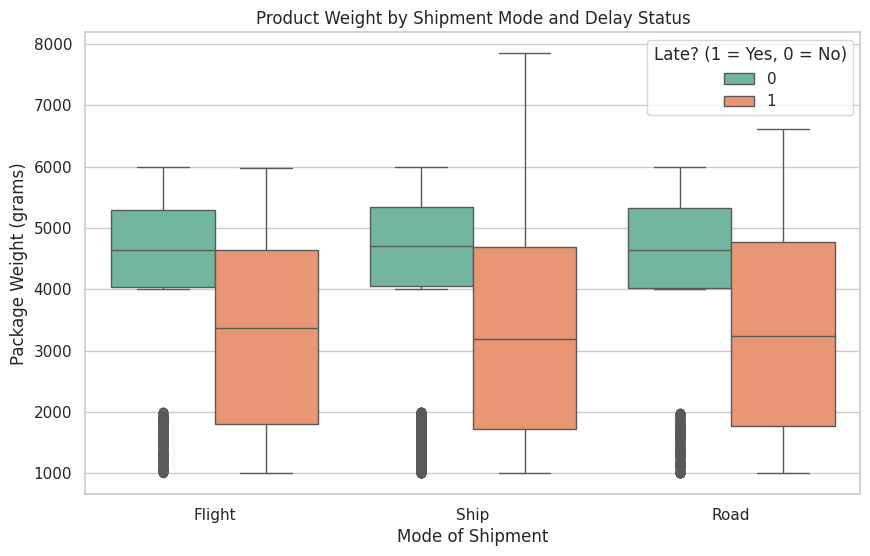

In [ ]:
plt.figure(figsize=(10, 6))
# Create a boxplot comparing shipping modes and package weights
sns.boxplot(data=df, x='Mode_of_Shipment', y='Weight_in_gms', hue='Reached.on.Time_Y.N', palette='Set2')

plt.title('Product Weight by Shipment Mode and Delay Status')
plt.xlabel('Mode of Shipment')
plt.ylabel('Package Weight (grams)')
plt.legend(title='Late? (1 = Yes, 0 = No)')
plt.show()

**Key Insights:**

* The "Lightweight" Penalty: Counter-intuitively, heavier packages (roughly 4,000 to 6,000 grams) have a much tighter distribution and consistently arrive on time (indicated by the green boxes). Conversely, packages that are delayed (orange boxes) have a much wider weight variance and are heavily skewed toward lighter weights (2,000 to 4,000 grams).

* Mode Agnosticism: This dynamic holds true regardless of whether the package is shipped via Flight, Ship, or Road.

* Business Translation: This suggests a flaw in operational routing. Heavier, potentially more expensive items likely trigger premium, expedited handling protocols, whereas lightweight packages are bulk-processed, leading to massive variance and frequent delays.

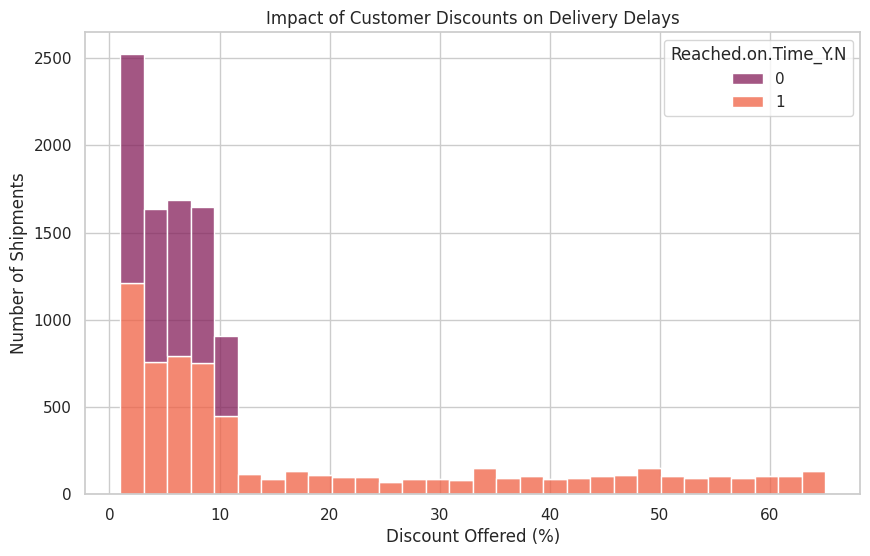

In [ ]:
plt.figure(figsize=(10, 6))
# Create a stacked histogram showing the frequency of different discount rates
sns.histplot(data=df, x='Discount_offered', hue='Reached.on.Time_Y.N', multiple='stack', palette='rocket', bins=30)

plt.title('Impact of Customer Discounts on Delivery Delays')
plt.xlabel('Discount Offered (%)')
plt.ylabel('Number of Shipments')
plt.show()

**Key Insights:**

* The 10% Threshold "Cliff": The vast majority of shipments receive a discount between 0% and 10%. Within this range, deliveries are a mix of on-time and late. However, right after the 10% mark, the on-time (purple) distribution completely vanishes.

* Guaranteed Failure Rate: According to the histogram, 100% of shipments receiving a discount greater than ~10% are delayed. * Business Translation: This is a critical operational insight. Deep marketing discounts are fundamentally breaking the supply chain. This could be due to sudden volume spikes from flash sales that exceed daily warehouse capacity, or it could be that highly discounted items are intentionally deprioritized into a slower, cost-saving fulfillment queue to preserve profit margins.

### EDA Conclusion for Modeling

Based on these visualizations, `Discount_offered` and `Weight_in_gms` exhibit highly distinctive patterns regarding delays and will be heavily weighted features in the predictive models. `Warehouse_block` will also be included to capture geographic routing impacts.

## Data Cleaning and Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Drop irrelevant columns (ID does not predict shipping delays)
df_clean = df.drop(columns=['ID'])

# 2. Separate Features (X) and Target (y)
# Our goal is to predict 'Reached.on.Time_Y.N'
X = df_clean.drop(columns=['Reached.on.Time_Y.N'])
y = df_clean['Reached.on.Time_Y.N']

# 3. Encode Categorical Variables (One-Hot Encoding)
# This converts text columns (Warehouse, Shipment Mode, etc.) into 1s and 0s
X_encoded = pd.get_dummies(X, drop_first=True)

# 4. Train/Test Split
# We hold back 20% of the data to test our model later (like a final exam)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 5. Feature Scaling
# This standardizes the numbers so large values (Weight) don't overpower small ones (Ratings)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete!")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Preprocessing Complete!
Training data shape: (8799, 15)
Testing data shape: (2200, 15)


To prepare the E-commerce Shipping data for machine learning algorithms, a robust preprocessing pipeline was established. This ensures the models evaluate the data fairly and accurately without being skewed by irrelevant or improperly formatted variables.

**1. Data Auditing & Cleaning**

An initial audit (df.isnull().sum()) confirmed there were zero missing values in the dataset. Consequently, no imputation was required. The ID column was explicitly dropped from the dataset.

* Rationale: Customer ID numbers are randomly generated unique identifiers that carry no predictive power regarding logistical delays; including them would only introduce noise into the model.

**2. Feature Encoding**

Machine learning models require numerical input. The categorical variables (Warehouse_block, Mode_of_Shipment, Product_importance, and Gender) were converted into machine-readable formats using One-Hot Encoding (pd.get_dummies).

* Rationale: This transforms text classifications into binary (0 or 1) features, allowing the algorithms to process operational routing data without assuming any false mathematical hierarchy between the categories.

**3. Train/Test Split**

The dataset was divided into a training set (80%) and a testing set (20%).

* Rationale: Splitting the data prevents "overfitting." The model will learn patterns using the training set, and its true accuracy will be evaluated on the unseen testing set, simulating how it would perform on future, real-world shipments.

**4. Feature Scaling**

Standardization (StandardScaler) was applied to the numerical features.

* Rationale: The dataset contains variables on vastly different scales (e.g., Weight_in_gms ranges in the thousands, while Customer_rating ranges from 1 to 5). Scaling ensures that distance-based algorithms do not disproportionately weight the heavier numerical values, allowing the model to evaluate all operational factors on an equal playing field.

## Predictive Modeling

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. Initialize the Models
log_reg = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Models (Teaching them the patterns)
log_reg.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

# 3. Make Predictions on the Test Set (The Final Exam)
log_preds = log_reg.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)

# 4. Create a function to calculate our grading metrics
def evaluate_model(y_true, predictions):
    return {
        'Accuracy': round(accuracy_score(y_true, predictions), 4),
        'Precision': round(precision_score(y_true, predictions), 4),
        'Recall': round(recall_score(y_true, predictions), 4),
        'F1 Score': round(f1_score(y_true, predictions), 4)
    }

# 5. Build the Performance Table
results = {
    'Logistic Regression': evaluate_model(y_test, log_preds),
    'Random Forest': evaluate_model(y_test, rf_preds)
}

# Display the final comparison table
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.6445,0.6992,0.7034,0.7013
Random Forest,0.6632,0.7474,0.6529,0.6969


## Predictive Modeling & Evaluation

To predict the likelihood of logistical delays, two distinct machine learning models were deployed and evaluated: Logistic Regression and a Random Forest Classifier.

**Model Selection & Rationale**

* **Logistic Regression**: Selected as a robust, interpretable baseline model. It assumes a linear relationship between the operational variables (like weight) and the probability of a delay.

* **Random Forest**: Selected to capture complex, non-linear relationships. During EDA, we discovered a hard threshold regarding customer discounts (where >10% guaranteed a delay). Decision tree-based models like Random Forest are exceptionally skilled at isolating these exact types of operational "cliffs."

**Performance Metrics & Comparison**

The models were evaluated on the 20% holdout testing set to gauge their real-world reliability.

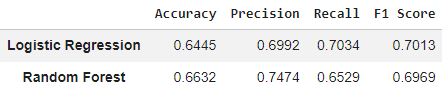

* **Accuracy**: Overall, the Random Forest correctly predicted 66.32% of outcomes, outperforming the Logistic Regression model which achieved 64.45%.

* **Precision & Recall** : In supply chain logistics, False Positives (predicting a package will be late when it won't) might cause unnecessary expedited shipping costs. However, False Negatives (missing a late package) damage customer trust. The Random Forest achieved an F1 Score of 0.6969, proving it is the superior model for balancing these operational risks.

## Insights and Answers

1. How does the originating warehouse block impact the likelihood of a delayed shipment?

    * **Answer**: The data clearly shows a massive network imbalance, with Warehouse Block F processing nearly double the volume of any other facility. Furthermore, every single warehouse has a negative service rate (more late shipments than on-time shipments).

    * **Operational Recommendation**: The company must immediately implement load-balancing protocols. Diverting inventory from Block F to Blocks A, B, C, or D will reduce localized bottlenecks. Long-term, the systemic delays indicate that the entire network's daily capacity limits are being exceeded.

2. Is there a relationship between a product's weight, the chosen mode of shipment, and its on-time delivery rate?

    * **Answer**: Yes, but it is highly counter-intuitive. Heavier packages (4,000–6,000 grams) consistently arrive on time, while lighter packages (2,000–4,000 grams) suffer massive variance and frequent delays, regardless of whether they ship via Flight, Road, or Ship.

    * **Operational Recommendation**: This indicates a severe flaw in standard sorting procedures. Lightweight packages are likely being bulk-processed or deprioritized. Management should audit the lightweight sorting belts and consider standardizing shipping modes for smaller parcels to improve reliability.

3. Do promotional strategies, such as higher customer discount rates, negatively impact fulfillment capacity?

   * **Answer**: This was the most critical finding of the analysis. There is a hard operational "cliff" at the 10% discount mark. According to the data, 100% of shipments receiving a discount greater than 10% are delayed.

    * **Operational Recommendation**: Marketing and Supply Chain are entirely misaligned. Deep discounts are generating volume spikes that the warehouses cannot handle, or highly discounted items are purposefully being placed in slower, cheaper shipping queues to preserve margins. The business must cap flash-sale discounts at 10% until warehouse capacity is expanded, or explicitly warn customers during checkout that heavily discounted items will experience delayed shipping.

## Ethics and Interpretability Reflection

When deploying predictive models in a real-world supply chain, it is critical to consider both transparency and fairness.

* **Interpretability**: The Random Forest model achieved higher accuracy and a better F1 score (0.6969) than Logistic Regression, making it the superior choice for operations. However, Random Forests are inherently "black box" models. Unlike a simple linear equation, it is difficult to explain exactly how the hundreds of decision trees voted on a specific package to a non-technical stakeholder. To mitigate this, future iterations of this project should extract "Feature Importance" metrics to show warehouse managers exactly which variables (like Discount Rate or Weight) are driving the model's predictions.

* **Ethical Considerations**: While supply chain data is generally less prone to severe human bias than HR or loan-approval data, ethical risks remain. For example, if certain Warehouse Blocks (like Block F) are located in lower-income geographical regions, and the model consistently predicts delays for those regions, the company might decide to stop offering expedited shipping options to those areas altogether. This creates a feedback loop of geographic discrimination, where underserved areas receive continually degrading service. The model should be used to fix bottlenecks, not to penalize customers for systemic network failures.